# Stage 1 and Stage 2 Visualization Walkthrough

This notebook explains and visualizes the work completed in the first two implementation stages of the repository.

It focuses on:

- stage 1: the Manhattan study-area definition, 15-minute demand matrix, split construction, and preprocessing artifacts
- stage 2: the first baseline benchmark results and one qualitative forecast comparison between persistence and LSTM

The notebook is intentionally built on top of the exact artifacts already generated in the repository rather than synthetic examples.

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

try:
    from IPython.display import HTML, SVG, display
except ImportError:
    class HTML(str):
        pass

    class SVG(str):
        pass

    def display(obj):
        print(obj)


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from lpe_stgtn.data.datasets import load_processed_dataset
from lpe_stgtn.models.baselines.lstm import LSTMBaseline
from lpe_stgtn.models.baselines.persistence import PersistenceBaseline

REPO_ROOT

PosixPath('/Users/hrishikeshalikatte/Desktop/Ride-hailing')

In [2]:
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "nyc_yellow_taxi_2018_manhattan_pickups_15min"
PERSISTENCE_REPORT = REPO_ROOT / "artifacts" / "reports" / "baselines" / "nyc_persistence_baseline.json"
LSTM_REPORT = REPO_ROOT / "artifacts" / "reports" / "baselines" / "nyc_lstm_baseline.json"

bundle = load_processed_dataset(PROCESSED_DIR)
metadata = json.loads((PROCESSED_DIR / "metadata.json").read_text(encoding="utf-8"))
persistence_report = json.loads(PERSISTENCE_REPORT.read_text(encoding="utf-8"))
lstm_report = json.loads(LSTM_REPORT.read_text(encoding="utf-8"))

demand_df = pd.read_parquet(PROCESSED_DIR / "demand_matrix.parquet")
demand_df["timestamp"] = pd.to_datetime(demand_df["timestamp"])
zone_columns = [column for column in demand_df.columns if column.startswith("zone_")]
demand_only = demand_df.set_index("timestamp")[zone_columns]

summary = pd.Series(
    {
        "num_time_steps": metadata["num_time_steps"],
        "num_zones": metadata["num_zones"],
        "history_steps": metadata["history_steps"],
        "forecast_steps": metadata["forecast_steps"],
        "total_pickups": metadata["total_pickups"],
        "train_mean": round(metadata["normalization"]["train_mean"], 6),
        "train_std": round(metadata["normalization"]["train_std"], 6),
    }
)

summary.to_frame("value")

,value
num_time_steps,3.504000e+04
num_zones,6.800000e+01
history_steps,1.200000e+01
forecast_steps,1.200000e+01
total_pickups,9.316256e+07
train_mean,4.038078e+01
train_std,4.961823e+01


In [3]:
def html_table(frame: pd.DataFrame, *, max_rows: int | None = None) -> HTML:
    view = frame.head(max_rows) if max_rows is not None else frame
    return HTML(view.to_html(index=False, border=0))


def _color_for_value(value: float, vmin: float, vmax: float) -> str:
    if vmax <= vmin:
        ratio = 0.5
    else:
        ratio = (value - vmin) / (vmax - vmin)
    ratio = max(0.0, min(1.0, ratio))
    red = int(15 + 220 * ratio)
    green = int(70 + 80 * (1.0 - abs(ratio - 0.5) * 2.0))
    blue = int(245 - 190 * ratio)
    return f"rgb({red},{green},{blue})"


def render_heatmap(frame: pd.DataFrame, *, title: str = "", precision: int = 1) -> HTML:
    values = frame.to_numpy(dtype=float)
    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))
    header_cells = "".join(
        f"<th style='position:sticky;top:0;background:#fff;padding:4px 6px;font-size:11px'>{column}</th>"
        for column in frame.columns
    )
    rows = [f"<tr><th style='background:#fff'></th>{header_cells}</tr>"]
    for row_label, row_values in zip(frame.index, values, strict=True):
        cell_html = "".join(
            (
                f"<td title='{float(value):.{precision}f}' "
                f"style='background:{_color_for_value(float(value), vmin, vmax)};padding:4px 6px;font-size:10px;text-align:center'>"
                f"{float(value):.{precision}f}</td>"
            )
            for value in row_values
        )
        rows.append(
            f"<tr><th style='text-align:left;padding:4px 6px;background:#fff;font-size:11px'>{row_label}</th>{cell_html}</tr>"
        )
    title_html = f"<h4 style='margin:0 0 8px 0'>{title}</h4>" if title else ""
    table_html = f"<table style='border-collapse:collapse'>{''.join(rows)}</table>"
    return HTML(
        f"{title_html}<div style='overflow:auto;max-height:640px;border:1px solid #ddd;padding:6px'>{table_html}</div>"
    )


def render_line_chart(
    series_map: dict[str, np.ndarray],
    *,
    title: str,
    width: int = 900,
    height: int = 320,
    marker_x: int | None = None,
) -> SVG:
    max_len = max(len(values) for values in series_map.values())
    all_values = np.concatenate([np.asarray(values, dtype=float) for values in series_map.values()])
    ymin = float(np.min(all_values))
    ymax = float(np.max(all_values))
    if math.isclose(ymin, ymax):
        ymax = ymin + 1.0

    pad_left, pad_right, pad_top, pad_bottom = 55, 20, 24, 40
    plot_width = width - pad_left - pad_right
    plot_height = height - pad_top - pad_bottom
    colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#8c564b"]

    def x_coord(index: int) -> float:
        if max_len == 1:
            return pad_left + plot_width / 2
        return pad_left + plot_width * index / (max_len - 1)

    def y_coord(value: float) -> float:
        ratio = (value - ymin) / (ymax - ymin)
        return pad_top + plot_height * (1.0 - ratio)

    parts = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}'>",
        f"<text x='{width / 2}' y='16' text-anchor='middle' font-size='14' font-weight='bold'>{title}</text>",
        f"<line x1='{pad_left}' y1='{pad_top}' x2='{pad_left}' y2='{pad_top + plot_height}' stroke='#333'/>",
        f"<line x1='{pad_left}' y1='{pad_top + plot_height}' x2='{pad_left + plot_width}' y2='{pad_top + plot_height}' stroke='#333'/>",
    ]
    if marker_x is not None:
        marker = x_coord(marker_x)
        parts.append(
            f"<line x1='{marker}' y1='{pad_top}' x2='{marker}' y2='{pad_top + plot_height}' stroke='#777' stroke-dasharray='4 4'/>"
        )

    for color_index, (label, values) in enumerate(series_map.items()):
        color = colors[color_index % len(colors)]
        values = np.asarray(values, dtype=float)
        points = " ".join(f"{x_coord(idx)},{y_coord(value)}" for idx, value in enumerate(values))
        parts.append(f"<polyline fill='none' stroke='{color}' stroke-width='2' points='{points}'/>")
        parts.append(
            f"<text x='{pad_left + 8}' y='{pad_top + 16 + color_index * 16}' fill='{color}' font-size='12'>{label}</text>"
        )

    for tick_value in np.linspace(ymin, ymax, 5):
        y = y_coord(float(tick_value))
        parts.append(f"<line x1='{pad_left - 4}' y1='{y}' x2='{pad_left}' y2='{y}' stroke='#333'/>")
        parts.append(f"<text x='{pad_left - 8}' y='{y + 4}' text-anchor='end' font-size='11'>{tick_value:.1f}</text>")

    parts.append("</svg>")
    return SVG("".join(parts))


def render_grouped_bar_chart(
    frame: pd.DataFrame,
    *,
    title: str,
    width: int = 780,
    height: int = 320,
) -> SVG:
    values = frame.to_numpy(dtype=float)
    max_value = max(float(values.max()) if values.size else 0.0, 1.0)
    pad_left, pad_right, pad_top, pad_bottom = 60, 20, 24, 50
    plot_width = width - pad_left - pad_right
    plot_height = height - pad_top - pad_bottom
    group_count = max(len(frame.index), 1)
    series_count = max(len(frame.columns), 1)
    group_width = plot_width / group_count
    bar_width = group_width / (series_count + 1)
    colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]

    parts = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}'>",
        f"<text x='{width / 2}' y='16' text-anchor='middle' font-size='14' font-weight='bold'>{title}</text>",
        f"<line x1='{pad_left}' y1='{pad_top}' x2='{pad_left}' y2='{pad_top + plot_height}' stroke='#333'/>",
        f"<line x1='{pad_left}' y1='{pad_top + plot_height}' x2='{pad_left + plot_width}' y2='{pad_top + plot_height}' stroke='#333'/>",
    ]

    for tick_value in np.linspace(0.0, max_value, 5):
        y = pad_top + plot_height * (1.0 - tick_value / max_value)
        parts.append(f"<line x1='{pad_left - 4}' y1='{y}' x2='{pad_left}' y2='{y}' stroke='#333'/>")
        parts.append(f"<text x='{pad_left - 8}' y='{y + 4}' text-anchor='end' font-size='11'>{tick_value:.1f}</text>")

    for group_index, (row_label, row_values) in enumerate(frame.iterrows()):
        base_x = pad_left + group_index * group_width
        parts.append(
            f"<text x='{base_x + group_width / 2}' y='{pad_top + plot_height + 18}' text-anchor='middle' font-size='12'>{row_label}</text>"
        )
        for series_index, (column, value) in enumerate(row_values.items()):
            color = colors[series_index % len(colors)]
            bar_height = plot_height * (float(value) / max_value)
            x = base_x + (series_index + 0.5) * bar_width
            y = pad_top + plot_height - bar_height
            parts.append(
                f"<rect x='{x}' y='{y}' width='{bar_width * 0.8}' height='{bar_height}' fill='{color}'/>"
            )
            parts.append(
                f"<text x='{x + bar_width * 0.4}' y='{y - 4}' text-anchor='middle' font-size='11'>{float(value):.2f}</text>"
            )

    for series_index, column in enumerate(frame.columns):
        color = colors[series_index % len(colors)]
        legend_x = pad_left + 10 + series_index * 120
        parts.append(f"<rect x='{legend_x}' y='{pad_top + 8}' width='12' height='12' fill='{color}'/>")
        parts.append(
            f"<text x='{legend_x + 18}' y='{pad_top + 18}' font-size='12'>{column}</text>"
        )

    parts.append("</svg>")
    return SVG("".join(parts))

## Stage 1: What The Preprocessing Pipeline Built

Stage 1 takes the raw 2018 NYC Yellow Taxi parquet files and turns them into one reproducible, model-ready demand dataset.

Key implementation choices reflected below:

- demand is defined as pickup counts
- the study area is Manhattan TLC zones
- the current provisional paper-faithful rule excludes `LocationID 103`, giving `68` zones
- timestamps are clipped to the file month and the full 2018 range before aggregation
- demand is aggregated into 15-minute bins and concatenated into a dense `(35040, 68)` matrix
- chronological train/validation/test splits are `60/20/20`
- train-only normalization statistics are saved for later models

borough,available_zone_count,included_zone_count,expected_zone_count,excluded_location_ids
Manhattan,69,68,68,[103]


name,step_start,step_end,num_steps,sample_start,sample_end,num_samples
train,0,21024,21024,0,21001,21001
validation,21024,28032,7008,21024,28009,6985
test,28032,35040,7008,28032,35017,6985


file_name,study_area_pickup_count,active_zone_count,min_timestamp,max_timestamp
yellow_tripdata_2018-01.parquet,7966147,67,2018-01-01T00:00:00,2018-01-31T23:45:00
yellow_tripdata_2018-02.parquet,7767934,67,2018-02-01T00:00:00,2018-02-28T23:45:00
yellow_tripdata_2018-03.parquet,8568277,67,2018-03-01T00:00:00,2018-03-31T23:45:00
yellow_tripdata_2018-04.parquet,8428985,67,2018-04-01T00:00:00,2018-04-30T23:45:00
yellow_tripdata_2018-05.parquet,8350366,68,2018-05-01T00:00:00,2018-05-31T23:45:00
yellow_tripdata_2018-06.parquet,7879077,67,2018-06-01T00:00:00,2018-06-30T23:45:00
yellow_tripdata_2018-07.parquet,7092723,67,2018-07-01T00:00:00,2018-07-31T23:45:00
yellow_tripdata_2018-08.parquet,7087359,67,2018-08-01T00:00:00,2018-08-31T23:45:00
yellow_tripdata_2018-09.parquet,7278927,67,2018-09-01T00:00:00,2018-09-30T23:45:00
yellow_tripdata_2018-10.parquet,7976350,67,2018-10-01T00:00:00,2018-10-31T23:45:00


,2018-01-01 00:00:00,2018-01-02 00:00:00,2018-01-03 00:00:00,2018-01-04 00:00:00,2018-01-05 00:00:00,2018-01-06 00:00:00,2018-01-07 00:00:00,2018-01-08 00:00:00,2018-01-09 00:00:00,2018-01-10 00:00:00,2018-01-11 00:00:00,2018-01-12 00:00:00,2018-01-13 00:00:00,2018-01-14 00:00:00,2018-01-15 00:00:00,2018-01-16 00:00:00,2018-01-17 00:00:00,2018-01-18 00:00:00,2018-01-19 00:00:00,2018-01-20 00:00:00,2018-01-21 00:00:00,2018-01-22 00:00:00,2018-01-23 00:00:00,2018-01-24 00:00:00,2018-01-25 00:00:00,2018-01-26 00:00:00,2018-01-27 00:00:00,2018-01-28 00:00:00,2018-01-29 00:00:00,2018-01-30 00:00:00,2018-01-31 00:00:00
zone_237,6175,9208,11123,4618,10663,9585,7637,11567,13295,13572,13694,13399,10448,8262,9734,13192,14117,15867,14322,10963,7884,12180,13555,14959,15946,14582,10990,7895,12259,14163,15149
zone_161,8139,10761,12238,5428,10455,8592,6500,11605,12532,13362,13595,12513,9794,8172,8961,13826,15138,15617,13422,7457,6307,12474,14581,15344,15255,13537,9331,6859,12706,14749,15703
zone_236,5652,9418,10612,4268,10791,9910,8458,11804,12601,12762,13020,12825,10416,8435,9300,12687,13092,14218,13711,10795,8394,11820,12570,13290,13768,13807,10305,8201,11710,13345,13716
zone_162,6082,8721,10750,5025,9461,6451,5317,10053,11357,11584,12249,11345,7618,6953,8213,12092,13452,14168,11732,7367,5456,10510,12327,13263,13716,11973,7217,6027,10874,12968,14012
zone_186,9283,9715,10324,4782,9068,8737,7773,8711,9842,10084,10175,11207,10839,9218,9395,10648,10999,11880,10759,8848,7829,8877,9285,9856,10321,9777,8682,6383,8564,10479,10199
zone_230,8713,9217,9954,6374,9813,10101,8211,7645,9349,9824,9934,10616,11714,12108,9226,11401,12284,11652,10657,7724,7905,8141,10696,11594,11455,11121,9962,8931,9645,11308,11946
zone_170,6994,7463,8828,3900,8677,7233,6078,8595,9733,10059,10719,10472,8554,7284,7240,10002,10636,11572,10964,8000,6160,8743,10064,10847,11704,11381,8332,6427,9197,10688,11377
zone_48,9006,7452,8122,5032,8474,9090,7695,7389,8010,8283,8772,9776,10714,10271,7803,8722,8949,9459,9684,10079,8323,7491,8319,9088,10091,10386,10248,8837,7303,8745,8995
zone_234,5626,6729,8370,3156,8318,8799,6796,8194,9486,9914,10382,10549,10399,8842,7592,9846,10808,11375,10814,9709,7670,8626,10049,11235,11490,11329,9683,7498,8800,10448,11444
zone_142,7247,6954,7931,3895,8654,9926,7809,7723,8960,8666,8853,9614,10381,9213,7591,8406,8746,9900,9799,7696,7524,8014,8564,9449,9811,9758,10052,7556,7685,8814,8896


,00:00,00:15,00:30,00:45,01:00,01:15,01:30,01:45,02:00,02:15,02:30,02:45,03:00,03:15,03:30,03:45,04:00,04:15,04:30,04:45,05:00,05:15,05:30,05:45,06:00,06:15,06:30,06:45,07:00,07:15,07:30,07:45,08:00,08:15,08:30,08:45,09:00,09:15,09:30,09:45,10:00,10:15,10:30,10:45,11:00,11:15,11:30,11:45,12:00,12:15,12:30,12:45,13:00,13:15,13:30,13:45,14:00,14:15,14:30,14:45,15:00,15:15,15:30,15:45,16:00,16:15,16:30,16:45,17:00,17:15,17:30,17:45,18:00,18:15,18:30,18:45,19:00,19:15,19:30,19:45,20:00,20:15,20:30,20:45,21:00,21:15,21:30,21:45,22:00,22:15,22:30,22:45,23:00,23:15,23:30,23:45
zone_237,45.7,39.3,32.7,26.8,22.3,18.4,14.5,11.8,10.4,9.4,7.8,6.9,6.3,5.4,5.4,5.2,5.0,5.2,6.0,7.2,7.9,11.9,15.1,22.1,23.6,32.8,46.4,71.0,76.2,93.6,130.7,157.7,145.8,137.5,151.6,163.1,156.1,151.7,148.5,156.1,149.1,153.6,158.1,164.3,159.6,162.7,176.1,187.9,190.3,189.5,187.4,191.0,187.7,185.5,189.5,197.3,203.3,206.3,209.3,212.8,211.6,208.3,199.0,195.8,192.7,181.5,179.3,181.2,199.7,201.9,206.7,210.3,217.8,217.6,209.9,212.9,202.6,190.9,173.0,161.5,157.1,150.8,144.5,140.4,143.3,140.0,139.7,132.4,130.5,118.2,104.5,91.9,83.0,71.3,60.7,51.3
zone_161,88.2,78.0,63.6,54.2,46.8,39.3,32.7,25.9,22.9,18.6,16.8,14.2,12.7,11.3,10.4,9.8,9.8,9.2,9.1,8.7,9.0,9.6,11.5,21.8,22.7,27.2,33.6,46.8,50.7,55.0,62.8,68.6,72.1,76.1,90.1,91.7,92.5,95.5,102.1,107.7,109.6,115.2,122.9,129.8,134.8,141.6,153.0,161.1,163.0,162.3,160.2,161.3,161.4,163.1,172.4,175.1,179.0,180.7,179.9,178.7,178.3,171.7,168.9,166.3,167.2,156.2,151.4,150.2,157.5,162.7,170.7,174.5,181.6,178.7,184.6,190.5,193.7,195.1,194.7,194.4,191.7,181.9,175.5,173.1,177.6,165.9,162.6,166.8,163.7,159.3,158.7,155.7,143.6,122.9,107.7,97.5
zone_236,26.1,22.5,18.1,15.0,12.9,10.7,8.8,7.4,6.4,5.6,4.9,4.3,3.8,3.7,3.6,3.7,3.9,4.6,6.8,7.3,10.1,13.7,19.7,27.7,31.9,44.7,68.1,92.2,99.2,121.7,147.5,158.9,177.1,172.5,160.9,169.4,159.3,156.1,156.0,163.1,155.7,156.7,161.9,164.8,156.1,161.6,170.2,180.9,185.4,183.2,176.0,178.1,170.8,170.2,169.1,171.6,170.7,174.1,188.2,195.7,208.5,208.7,198.4,185.5,180.4,173.8,174.0,167.9,180.6,182.5,187.5,186.3,187.1,185.6,180.2,180.7,166.9,158.0,139.5,128.9,121.6,114.2,110.7,105.5,103.2,95.1,90.5,84.6,80.2,70.2,62.3,55.9,49.5,42.8,34.6,29.4
zone_162,64.8,58.9,45.6,43.2,36.6,31.2,27.1,23.2,20.9,17.2,14.7,12.8,11.9,10.6,9.6,9.7,11.2,10.2,10.5,10.4,9.9,11.3,15.0,35.1,31.7,39.1,52.0,68.7,68.4,78.3,85.4,94.9,96.4,99.8,117.0,118.5,113.3,115.3,111.4,115.7,109.4,116.4,113.7,119.3,117.4,121.7,128.4,141.5,134.4,136.4,128.6,133.2,125.7,131.2,131.7,138.4,134.1,137.8,135.9,139.0,131.7,130.1,126.1,131.0,127.1,124.0,122.9,133.5,152.5,166.0,165.8,175.0,177.8,181.4,182.6,188.4,186.2,188.3,179.8,182.6,173.7,171.1,162.0,174.9,169.9,166.3,155.0,164.8,147.5,131.5,119.9,124.1,103.4,88.1,77.3,75.9
zone_186,74.2,54.9,55.1,42.1,37.9,42.7,35.2,32.2,26.7,22.9,26.2,25.6,20.7,16.9,15.3,13.5,16.0,19.3,13.0,29.6,13.4,23.2,50.9,49.6,103.8,117.7,135.7,143.5,133.8,128.5,133.3,117.3,110.2,107.9,112.0,114.6,112.9,115.1,124.8,134.2,126.5,122.0,121.5,141.4,139.5,122.8,123.1,127.7,119.5,120.3,123.0,141.1,130.6,111.3,116.8,132.7,116.4,96.5,116.5,134.0,114.1,107.5,116.5,129.1,113.4,97.4,105.4,116.6,114.8,106.3,120.6,139.7,132.0,124.6,135.0,154.9,145.7,126.5,143.5,154.2,131.5,106.7,118.6,144.9,129.5,114.7,137.0,139.1,129.8,101.5,127.4,135.9,108.2,87.2,93.4,77.5
zone_230,124.4,111.8,96.7,84.8,75.4,64.0,56.8,49.2,45.2,40.6,37.0,33.7,31.3,28.6,28.9,30.3,37.5,32.2,25.5,21.3,20.7,19.3,20.9,23.2,25.5,27.2,34.6,42.9,46.2,49.3,57.6,63.1,69.9,74.2,79.4,82.2,84.3,86.7,92.3,94.7,96.9,98.1,102.2,103.5,105.5,106.4,109.7,112.4,115.5,109.9,104.3,100.5,103.3,104.8,108.6,106.7,109.6,110.0,108.2,106.1,108.5,106.7,108.3,110.0,112.0,109.0,114.0,116.5,122.8,128.4,139.2,147.3,153.6,157.2,161.1,161.2,156.3,156.5,153.5,149.8,143.2,141.6,144.2,153.0,158.6,163.4,172.4,182.6,170.8,181.1,197.6,195.5,176.1,154.9,141.6,131.5
zone_170,67.1,59.4,50.3,45.7,39.1,36.0,31.0,28.2,25.5,21.8,19.3,17.2,15.7,13.6,13.2,12.5,12.2,12.5,13.0,12.1,12.6,14.2,19.1,31.0,31.7,42.8,59.3,74.1,75.9,83.9,96.6,109.4

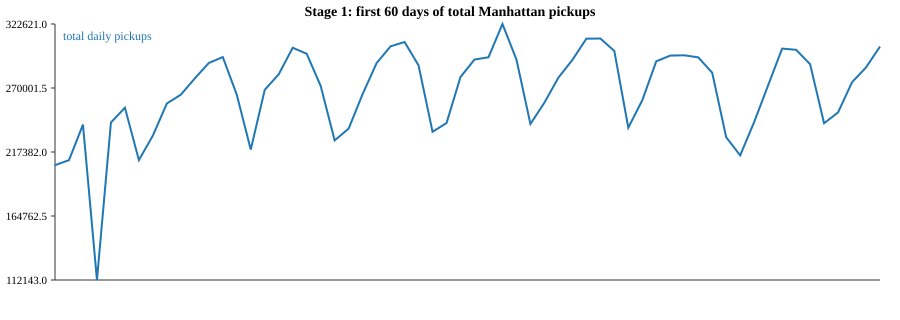

In [4]:
study_area_frame = pd.DataFrame([metadata["study_area_summary"]])[
    [
        "borough",
        "available_zone_count",
        "included_zone_count",
        "expected_zone_count",
        "excluded_location_ids",
    ]
]
split_frame = pd.DataFrame(metadata["splits"]).T.reset_index(drop=True)
monthly_frame = pd.DataFrame(metadata["monthly_stats"])[
    [
        "file_name",
        "study_area_pickup_count",
        "active_zone_count",
        "min_timestamp",
        "max_timestamp",
    ]
]

display(HTML("<h3>Study-area summary</h3>"))
display(html_table(study_area_frame))
display(HTML("<h3>Chronological split summary</h3>"))
display(html_table(split_frame))
display(HTML("<h3>Monthly aggregation summary</h3>"))
display(html_table(monthly_frame))

top_zones = demand_only.sum(axis=0).sort_values(ascending=False).head(20).index.tolist()
daily_zone_totals = demand_only[top_zones].resample("D").sum()
slot_index = ((demand_only.index.hour * 60 + demand_only.index.minute) // 15)
average_day_profile = demand_only[top_zones].groupby(slot_index).mean()
average_day_profile.index = [f"{(slot * 15) // 60:02d}:{(slot * 15) % 60:02d}" for slot in average_day_profile.index]
first_sixty_days = demand_only.sum(axis=1).resample("D").sum().iloc[:60]

display(render_heatmap(daily_zone_totals.head(31).T, title="January 2018 daily pickup totals for the 20 busiest zones", precision=0))
display(render_heatmap(average_day_profile.T, title="Average 15-minute pickup profile across 2018 for the 20 busiest zones", precision=1))
display(render_line_chart({"total daily pickups": first_sixty_days.to_numpy()}, title="Stage 1: first 60 days of total Manhattan pickups"))

## Stage 2: Baseline Benchmarks

Stage 2 adds the first benchmark models on top of the processed demand matrix.

Implemented baselines:

- `Persistence`: repeat the last observed timestep across the full forecast horizon
- `LSTM`: encode the 12-step history window and predict the next 12 steps in one shot

The goal here is not to match the paper yet. The goal is to create a stable performance floor so later graph-based models can be judged against something real.

,split,model,mae,rmse,mape
0,validation,Persistence,12.287365,22.423727,66070.557766
1,validation,LSTM,6.064351,10.727851,67356.450161
2,test,Persistence,12.563956,23.411007,70094.421459
3,test,LSTM,6.654453,12.291936,76449.309882


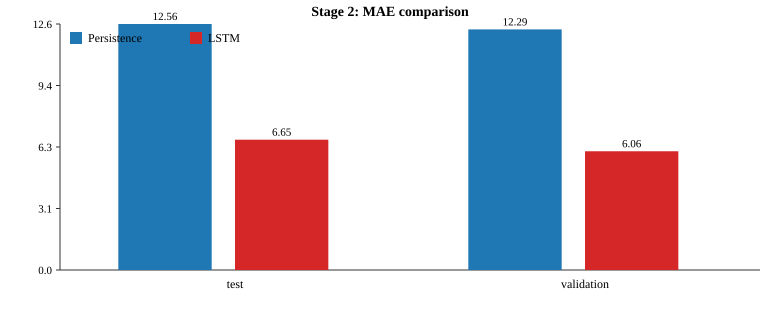

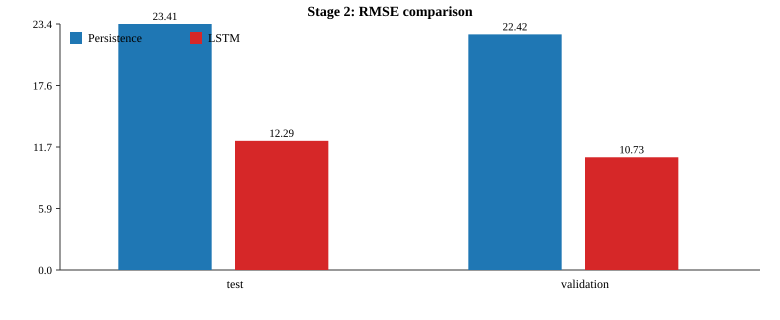

,epoch,train_loss,validation_loss,validation_mae,validation_rmse,validation_mape
0,1,0.213913,0.154955,7.676635,13.638064,153906.972905
1,2,0.148010,0.134578,6.659384,11.853749,108378.791173
2,3,0.138810,0.129522,6.414405,11.328552,93383.830016
3,4,0.134019,0.129023,6.391181,11.282427,91045.587346
4,5,0.130945,0.126673,6.273480,11.040219,78531.259462
5,6,0.128704,0.124946,6.185654,10.830612,91211.561849
6,7,0.127374,0.122763,6.079489,10.650453,78459.808615
7,8,0.125902,0.128913,6.385993,11.245019,71152.975829
8,9,0.124786,0.124862,6.183296,10.746576,82956.113520
9,10,0.123708,0.122456,6.064351,10.727851,67356.450161


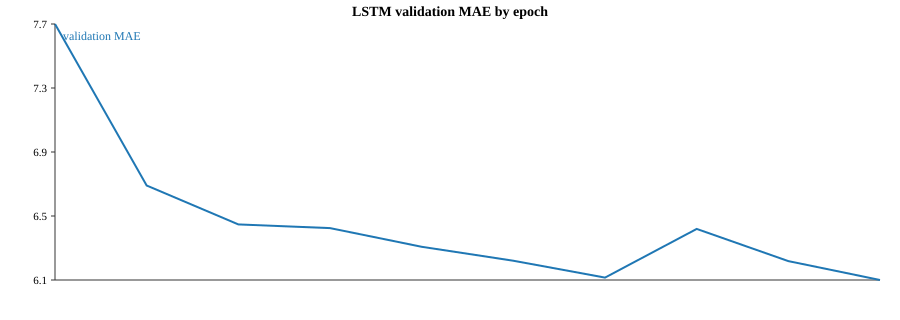

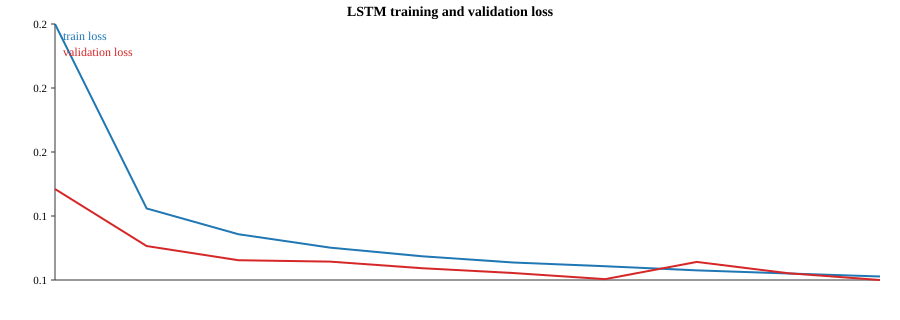

,split,mae_improvement_pct,rmse_improvement_pct
0,validation,50.645636,52.158482
1,test,47.035366,47.495057


In [5]:
metric_rows = []
for split_name in ["validation", "test"]:
    metric_rows.append({"split": split_name, "model": "Persistence", **persistence_report["metrics"][split_name]})
    metric_rows.append({"split": split_name, "model": "LSTM", **lstm_report["metrics"][split_name]})

metric_frame = pd.DataFrame(metric_rows)
display(HTML("<h3>Baseline metric table</h3>"))
display(metric_frame)

mae_chart = metric_frame.pivot(index="split", columns="model", values="mae")[["Persistence", "LSTM"]]
rmse_chart = metric_frame.pivot(index="split", columns="model", values="rmse")[["Persistence", "LSTM"]]
display(render_grouped_bar_chart(mae_chart, title="Stage 2: MAE comparison"))
display(render_grouped_bar_chart(rmse_chart, title="Stage 2: RMSE comparison"))

history_frame = pd.DataFrame(lstm_report["training_history"])
display(HTML("<h3>LSTM training history</h3>"))
display(history_frame)
display(render_line_chart({"validation MAE": history_frame["validation_mae"].to_numpy()}, title="LSTM validation MAE by epoch"))
display(render_line_chart({"train loss": history_frame["train_loss"].to_numpy(), "validation loss": history_frame["validation_loss"].to_numpy()}, title="LSTM training and validation loss"))

improvement_frame = pd.DataFrame(
    [
        {
            "split": split_name,
            "mae_improvement_pct": 100.0 * (persistence_report["metrics"][split_name]["mae"] - lstm_report["metrics"][split_name]["mae"]) / persistence_report["metrics"][split_name]["mae"],
            "rmse_improvement_pct": 100.0 * (persistence_report["metrics"][split_name]["rmse"] - lstm_report["metrics"][split_name]["rmse"]) / persistence_report["metrics"][split_name]["rmse"],
        }
        for split_name in ["validation", "test"]
    ]
)
display(HTML("<h3>LSTM improvement over persistence</h3>"))
display(improvement_frame)

,step,actual,persistence,lstm
0,0,2,2,2.000000
1,1,4,4,4.000000
2,2,3,3,3.000000
3,3,2,2,2.000000
4,4,3,3,3.000000
5,5,0,0,0.000000
6,6,2,2,2.000000
7,7,2,2,2.000000
8,8,4,4,4.000000
9,9,0,0,0.000000


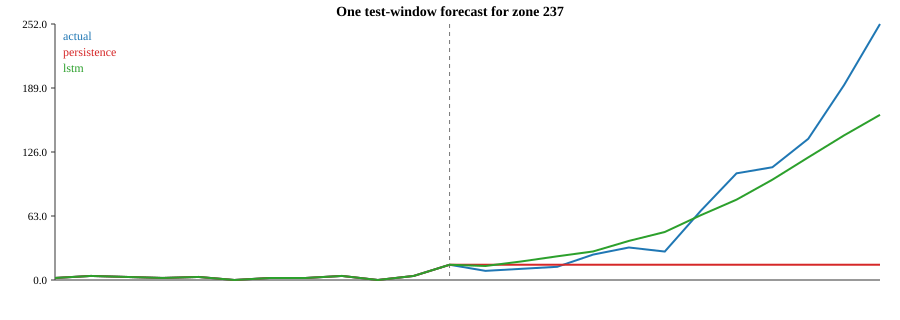

In [6]:
checkpoint = torch.load(lstm_report["checkpoint_path"], map_location="cpu")
checkpoint_config = checkpoint["model_config"]
model = LSTMBaseline(
    input_dim=bundle.num_zones,
    hidden_dim=int(checkpoint_config["hidden_dim"]),
    forecast_steps=bundle.forecast_steps,
    num_layers=int(checkpoint_config.get("num_layers", 1)),
    dropout=float(checkpoint_config.get("dropout", 0.0)),
)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

zone_totals = bundle.demand.sum(axis=0)
zone_index = int(zone_totals.argmax())
zone_id = int(bundle.zone_ids[zone_index])
sample_position = 200
sample_start = int(bundle.test_sample_start_indices[sample_position])

x_raw = bundle.demand[sample_start : sample_start + bundle.history_steps]
y_raw = bundle.demand[sample_start + bundle.history_steps : sample_start + bundle.history_steps + bundle.forecast_steps]
x_norm = bundle.normalized_demand[sample_start : sample_start + bundle.history_steps]

with torch.no_grad():
    lstm_pred_norm = model(torch.as_tensor(x_norm[None], dtype=torch.float32)).cpu().numpy()[0]

lstm_pred_raw = bundle.denormalize(lstm_pred_norm)
persistence_pred_raw = np.repeat(x_raw[-1:, :], bundle.forecast_steps, axis=0)

actual_series = np.concatenate([x_raw[:, zone_index], y_raw[:, zone_index]])
persistence_series = np.concatenate([x_raw[:, zone_index], persistence_pred_raw[:, zone_index]])
lstm_series = np.concatenate([x_raw[:, zone_index], lstm_pred_raw[:, zone_index]])

example_frame = pd.DataFrame(
    {
        "step": np.arange(bundle.history_steps + bundle.forecast_steps),
        "actual": actual_series,
        "persistence": persistence_series,
        "lstm": lstm_series,
    }
)

display(HTML(f"<h3>Qualitative forecast example for busiest zone {zone_id}</h3>"))
display(example_frame)
display(
    render_line_chart(
        {
            "actual": actual_series,
            "persistence": persistence_series,
            "lstm": lstm_series,
        },
        title=f"One test-window forecast for zone {zone_id}",
        marker_x=bundle.history_steps - 1,
    )
)

HTML(
    "<p><strong>Reading the chart:</strong> the dashed vertical line marks the boundary between the 12-step history window and the 12-step forecast horizon. The history segment is identical for all three lines, and the forecast segment shows how persistence and LSTM diverge from the actual future demand.</p>"
)